## **Exploratory Analysis**

In [134]:
import pandas as pd
import matplotlib.pyplot as plt

#import data (includes elevation, snowpack, total inflow, and calculated evaporation)
gsl_monthly_df = pd.read_csv('evaporation_data.csv')
#import tributary inflow for Bear River, Jordan River, and Weber River
inflow_df = pd.read_csv('gsl_inflow_monthly_acft.csv')

#convert date columns to datetime so they match when merged
gsl_monthly_df['date'] = pd.to_datetime(gsl_monthly_df['date'])
inflow_df['date'] = pd.to_datetime(inflow_df['date'])

#merge individual river columns into comprehensive_df
gsl_monthly_df = gsl_monthly_df.merge(
    #grab individual river columns from inflow dataset
    inflow_df[['date', 
               'Bear River (primary, near Corinne)_acft',
               'Bear River (upstream gap-fill)_acft',
               'Weber River (near Plain City)_acft',
               'Jordan River (Surplus Canal)_acft',
               'Jordan River (1700 South)_acft']],
    on='date',
    how='left'
)

#get rid of duplicates
gsl_monthly_df = gsl_monthly_df.drop(columns=[
    'Unnamed: 0',                          #leftover row index from saving to CSV
    'elev_ft_NGVD29',                      #duplicate of elevation_ft
    'Bear River (upstream gap-fill)_acft'  #duplicate of primary Bear River
])

#remane columns to be consistent and informative
gsl_monthly_df = gsl_monthly_df.rename(columns={
    'TOTAL_INFLOW_cfs_acft': 'total_inflow_cfs_acft',
    'Bear River (primary, near Corinne)_acft': 'bear_river_acft',
    'Weber River (near Plain City)_acft': 'weber_river_acft',
    'Jordan River (Surplus Canal)_acft': 'jordan_river_surplus_acft',
    'Jordan River (1700 South)_acft': 'jordan_river_1700_acft',
    'monthly_precip_inches': 'monthly_precip_in',
    'area_acre': 'SA_ac',          #length x width
    'area_acre_prior': 'SA_prior_month_ac',
    'volume_acreft': 'volume_acft',
    'precip_acreft': 'precip_acft',
    'evaporation_acreft': 'evaporation_acft',
})

print(gsl_monthly_df.head())
print(gsl_monthly_df.columns)

#save csv
gsl_monthly_df.to_csv('gsl_monthly_df.csv', index = False)


        date  year  month  elevation_ft  monthly_precip_in  \
0 1950-02-01  1950      2       4197.40               1.19   
1 1950-03-01  1950      3       4197.90               0.98   
2 1950-04-01  1950      4       4198.15               1.29   
3 1950-05-01  1950      5       4198.35               2.18   
4 1950-06-01  1950      6       4198.80               0.16   

   snow_water_equiv_in  volume_acft      SA_ac  SA_prior_month_ac  \
0                  NaN  13231625.08  879251.73          864498.36   
1                  NaN  13677742.99  905185.46          879251.73   
2                  NaN  13905660.50  918138.01          905185.46   
3                  NaN  14090506.69  928507.42          918138.01   
4                  NaN  14513327.20  951733.99          928507.42   

   prior_month_vol_acft    precip_acft  total_inflow_cfs_acft  \
0           13013628.81   85729.420700            330234.8985   
1           13231625.08   71805.557950            378388.3280   
2           13677

### **1. Water Level Trends**
   
The line-graph shows the Great Salt Lake's water elevation has changed drastically over the past 74 years. The lake peaked around 1987 at its highest level, then steadily declined to a record low in 2022. The zigzag pattern throughout likely reflects seasonal patterns of snowmelt/precipitation raising the lake elevation in the spring and evaporation bringing it down in the summer. 

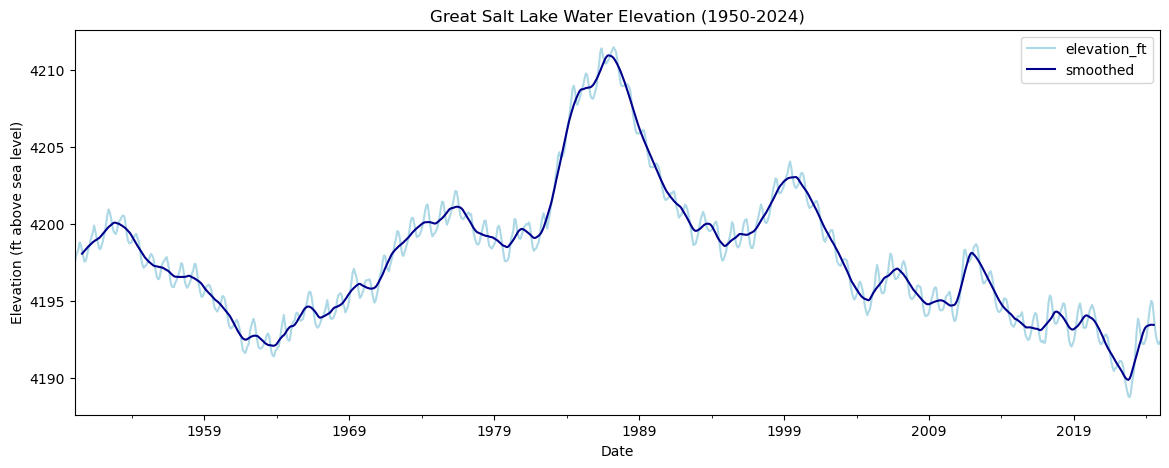

In [175]:
#Water elevation over time in a standard line graph 
#calculate 12-month rolling avg (to reduce noise for better visualization of data)
gsl_monthly_df['smoothed'] = gsl_monthly_df['elevation_ft'].rolling(window = 12, center = True).mean()

gsl_monthly_df.plot(
    x='date', 
    y=['elevation_ft', 'smoothed'], 
    figsize=(14, 5),
    title='Great Salt Lake Water Elevation (1950-2024)',
    color=['lightblue', 'darkblue']
)

plt.ylabel('Elevation (ft above sea level)')
plt.xlabel('Date')
plt.show()

### **2. Water Changes by Source Over Time**
   
*Tributary Data*<br>
The Bear River brings in the most water to the Great Salt Lake, consistently over time. There was a large amount of water going into the lake during the mid-1980s, then gradually returned to lower levels after that. Some data may be missing or estimated in the early years of the record, like the bear_river data in the early 1950s, which is something worth looking into and how it might affect the analysis. 

*Precipitation Data*<br>
Precipitation remained relatively stable over time with no clear long-term trend up or down. The mid-1980s stand out as a notably wetter period, consistent with the inflow spike also seen in the tributary data. 

*Evaporation Data*<br>
Water leaving the lake through evaporation also jumped in the mid-1980s, which makes sense because the lake was fuller and bigger, so more water was exposed to the sun and air. The negative values in this data are unusual and worth looking into before moving forward.

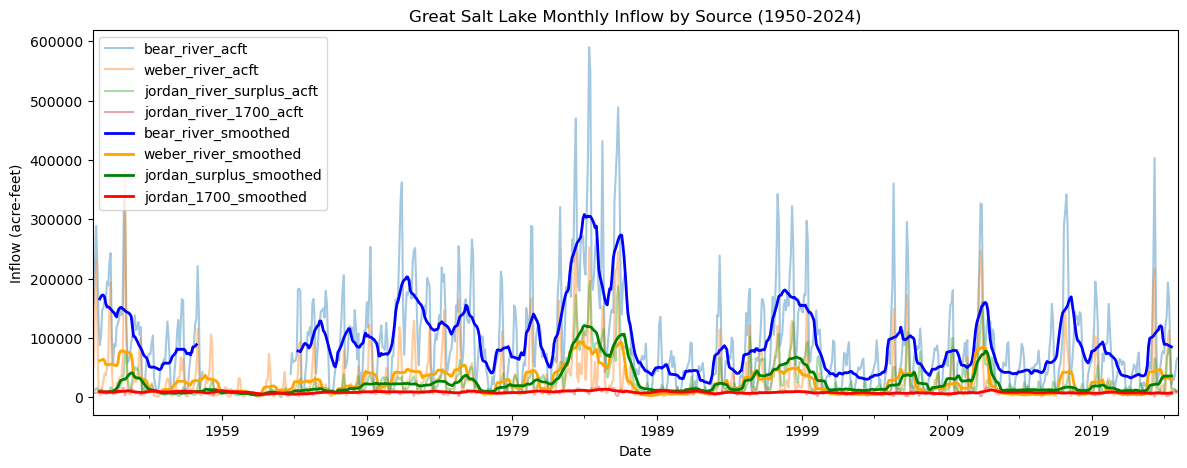

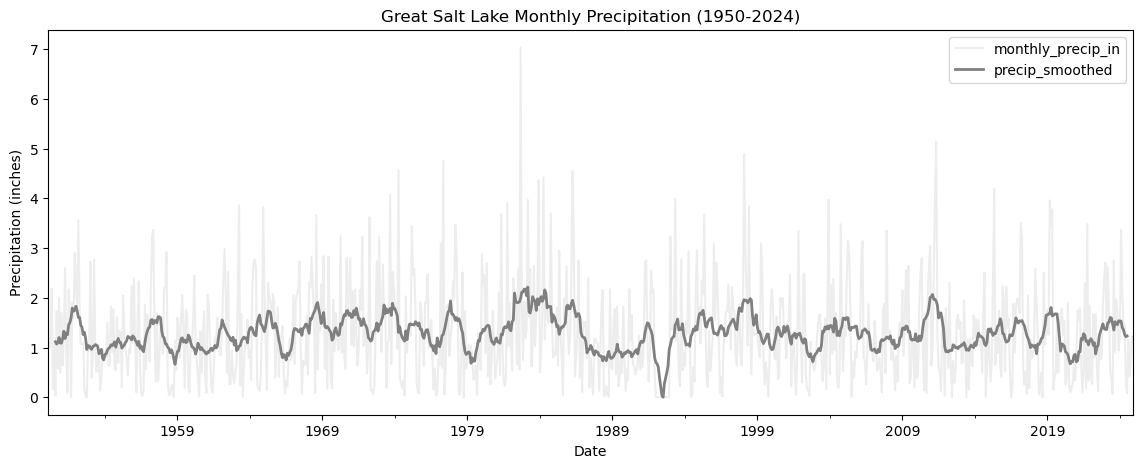

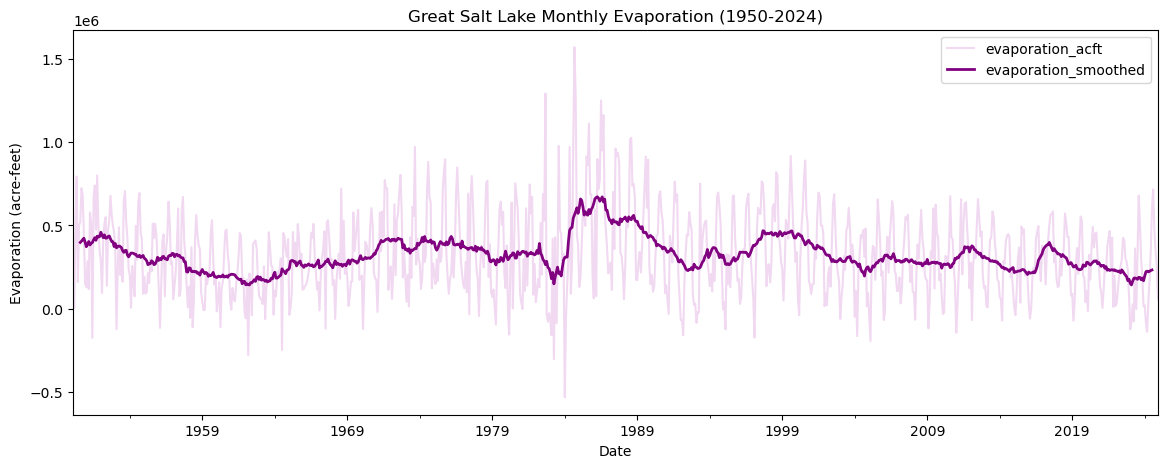

In [176]:
#calculate 12-month rolling avgs (to reduce noise for better visualization of data)
gsl_monthly_df['bear_river_smoothed'] = gsl_monthly_df['bear_river_acft'].rolling(window = 12, center= True).mean()
gsl_monthly_df['weber_river_smoothed'] = gsl_monthly_df['weber_river_acft'].rolling(window = 12, center = True).mean()
gsl_monthly_df['jordan_surplus_smoothed'] = gsl_monthly_df['jordan_river_surplus_acft'].rolling(window = 12, center = True).mean()
gsl_monthly_df['jordan_1700_smoothed'] = gsl_monthly_df['jordan_river_1700_acft'].rolling(window = 12, center = True).mean()
gsl_monthly_df['precip_smoothed'] = gsl_monthly_df['monthly_precip_in'].rolling(window = 12, center = True).mean()
gsl_monthly_df['evaporation_smoothed'] = gsl_monthly_df['evaporation_acft'].rolling(window = 12, center = True).mean()

# Plot each tributary (river inflow) source over time
gsl_monthly_df.plot(
    x = 'date',
    y = ['bear_river_acft', 'weber_river_acft', 'jordan_river_surplus_acft', 'jordan_river_1700_acft'],
    figsize = (14, 5),
    alpha = 0.4,
    title = 'Great Salt Lake Monthly Inflow by Source (1950-2024)'
)
gsl_monthly_df.plot(
    x = 'date',
    y = ['bear_river_smoothed', 'weber_river_smoothed', 'jordan_surplus_smoothed', 'jordan_1700_smoothed'],
    color = ['blue', 'orange', 'green', 'red'],
    linewidth = 2,
    ax = plt.gca()            #draw on top of current plot 
)
plt.ylabel('Inflow (acre-feet)')
plt.xlabel('Date')
plt.show()

# Plot precipitation over time
gsl_monthly_df.plot(
    x = 'date',
    y = 'monthly_precip_in',
    figsize = (14, 5),
    color = 'lightgray',
    alpha = 0.4,
    title='Great Salt Lake Monthly Precipitation (1950-2024)'
)
gsl_monthly_df.plot(
    x = 'date',
    y = 'precip_smoothed',
    color = 'gray',
    linewidth = 2,
    ax = plt.gca()
)
plt.ylabel('Precipitation (inches)')
plt.xlabel('Date')
plt.show()

# Plot evaporation over time
gsl_monthly_df.plot(
    x = 'date',
    y = 'evaporation_acft',
    figsize = (14, 5),
    color = 'plum',
    alpha = 0.4,
    title = 'Great Salt Lake Monthly Evaporation (1950-2024)'
)
gsl_monthly_df.plot(
    x = 'date',
    y = 'evaporation_smoothed',
    color = 'purple',
    linewidth = 2,
    ax = plt.gca()
)
plt.ylabel('Evaporation (acre-feet)')
plt.xlabel('Date')
plt.show()

### **3. Lake Elevation vs. Precipitation**

The scatter plot shows no clear relationship between lake elevation and monthly precipitation. Most months received between 0 and 2 inches of rain, yet the lake's water level varied widely regardless of how much rain fell that month. When the dots are colored by year, older decades show up at higher water levels while more recent years sit consistently lower, regarless of how much it rained. This suggests the lake has been shrinking due to reasons beyond monthly rainfall. 

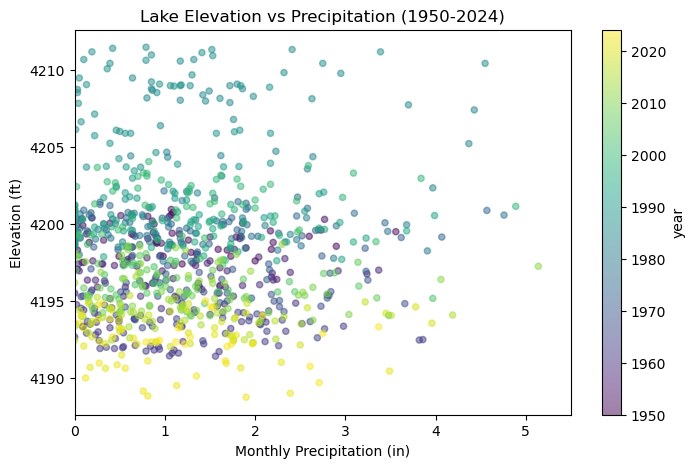

In [215]:
#scatter plot: precipitation vs GSL elevation
gsl_monthly_df.plot.scatter(
    x = 'monthly_precip_in', 
    y ='elevation_ft',
    c = 'year',               #color by year 
    colormap = 'viridis', 
    figsize = (8, 5), 
    title = 'Lake Elevation vs Precipitation (1950-2024)', 
    alpha = 0.5
)
plt.ylabel('Elevation (ft)')
plt.xlabel('Monthly Precipitation (in)')
plt.xlim(0, 5.5)              #limit x-axis to 5.5 inches (to visualize data better)
plt.show()


### **4. Descriptive Statistics**

*Summary Statistics*<br>
The Great Salt Lake averaged a water level of 4,197.94 feet over the record, ranging from a low of 4,188.73 feet to a high of 4,211.50 feet, with an average monthly rainfall of 1.28 inches. The Bear River was the largest source of water flowing into the lake, averaging 94,993 acre-feet per month, followed by the Weber River and the two Jordan River measurements. Some months show negative evaporation values which suggests the calculation may not be fully accounting for all water coming in, and is worth investigating further.

*Scatterplot matrix*<br>
The scatter plot grid shows that total water flowing into the lake is mostly driven by the Bear River. Most months have low river flow with occasional large spikes, meaning big inflow events are rare but impactful. The lake's water level does not appear strongly tied to any single monthly measurement, suggesting that long term patterns matter more than what happens in any given month. We might consider aggregating yearly data for further analysis. 

*Historical Monthly Data*<br>
The bar charts show that April receives the most rainfall on average and July the least. Evaporation is highest in August and lowest in February. Rivers bring in the most water in May and the least in August and September. Looking at all three bar charts together, spring is when the most water comes in through both rain and rivers, but summer is when the most water leaves through evaporation. This means the lake is gaining and losing water at very different times of year.

*Annual Precipitation*<br>
The line chart shows annual evaporation spiked around 1986 to 1987, which was the same period the lake was at its highest level. After that, evaporation gradually decreased over time. The most recent years show some of the lowest evaporation values in the entire record. The skewness of 0.95 indicates most years had moderate evaporation, with a small number of years pulling the average upward.

In [188]:
#summary statistics for all columns (monthly)
gsl_monthly_df.describe()

,date,year,month,elevation_ft,monthly_precip_in,snow_water_equiv_in,volume_acft,SA_ac,SA_prior_month_ac,prior_month_vol_acft,...,weber_river_acft,jordan_river_surplus_acft,jordan_river_1700_acft,smoothed,bear_river_smoothed,weber_river_smoothed,jordan_surplus_smoothed,jordan_1700_smoothed,precip_smoothed,evaporation_smoothed
count,899,899.000000,899.000000,899.000000,899.000000,424.000000,8.990000e+02,8.990000e+02,8.990000e+02,8.990000e+02,...,899.000000,899.000000,899.000000,888.000000,805.000000,888.000000,888.000000,888.000000,888.000000,888.000000
mean,1987-07-02 01:10:28.698553920,1987.041157,6.506118,4197.941513,1.278543,14.687736,1.422105e+07,9.100749e+05,9.103074e+05,1.422505e+07,...,26513.439646,24591.043802,8278.300409,4197.970547,94791.461264,26209.537101,24656.895294,8278.136208,1.281651,322712.621089
min,1950-02-01 00:00:00,1950.000000,1.000000,4188.730000,0.000000,0.000000,7.215839e+06,5.775942e+05,5.775942e+05,7.215839e+06,...,184.465500,0.000000,707.554120,4189.858333,23324.802958,2642.517875,3808.964638,5134.917858,0.000000,143425.576331
25%,1968-10-16 12:00:00,1968.000000,4.000000,4194.575000,0.540000,0.000000,1.096680e+07,7.326518e+05,7.333828e+05,1.097789e+07,...,5310.325375,9146.216025,6839.207175,4194.662708,50414.784792,8174.705990,11761.584744,7178.819566,1.048750,259676.407882
50%,1987-07-01 00:00:00,1987.000000,7.000000,4197.590000,1.120000,6.550000,1.339958e+07,8.890830e+05,8.890830e+05,1.339958e+07,...,9592.206000,13539.371000,8273.178500,4197.477500,80301.997500,21098.076271,16587.018750,8177.358921,1.264167,305173.309641
75%,2006-03-16 12:00:00,2006.000000,9.500000,4200.150000,1.800000,26.150000,1.584304e+07,1.032496e+06,1.032496e+06,1.584304e+07,...,29201.087000,27637.097250,9642.785250,4200.006458,121862.768875,39212.059438,27940.618205,9234.940459,1.476875,373844.352662
max,2024-12-01 00:00:00,2024.000000,12.000000,4211.500000,7.040000,75.100000,3.048158e+07,1.426610e+06,1.426610e+06,3.048158e+07,...,381308.040000,196306.995000,17944.724500,4210.969167,308133.419167,93739.879417,120899.283750,13588.462625,2.215833,672163.280795
std,NaN,21.637566,3.451012,4.416959,0.968189,17.646694,4.507721e+06,2.096282e+05,2.094613e+05,4.505050e+06,...,41155.355182,27599.284678,2424.817757,4.362916,56362.748416,20917.467895,22148.966253,1508.040296,0.319066,98324.608750


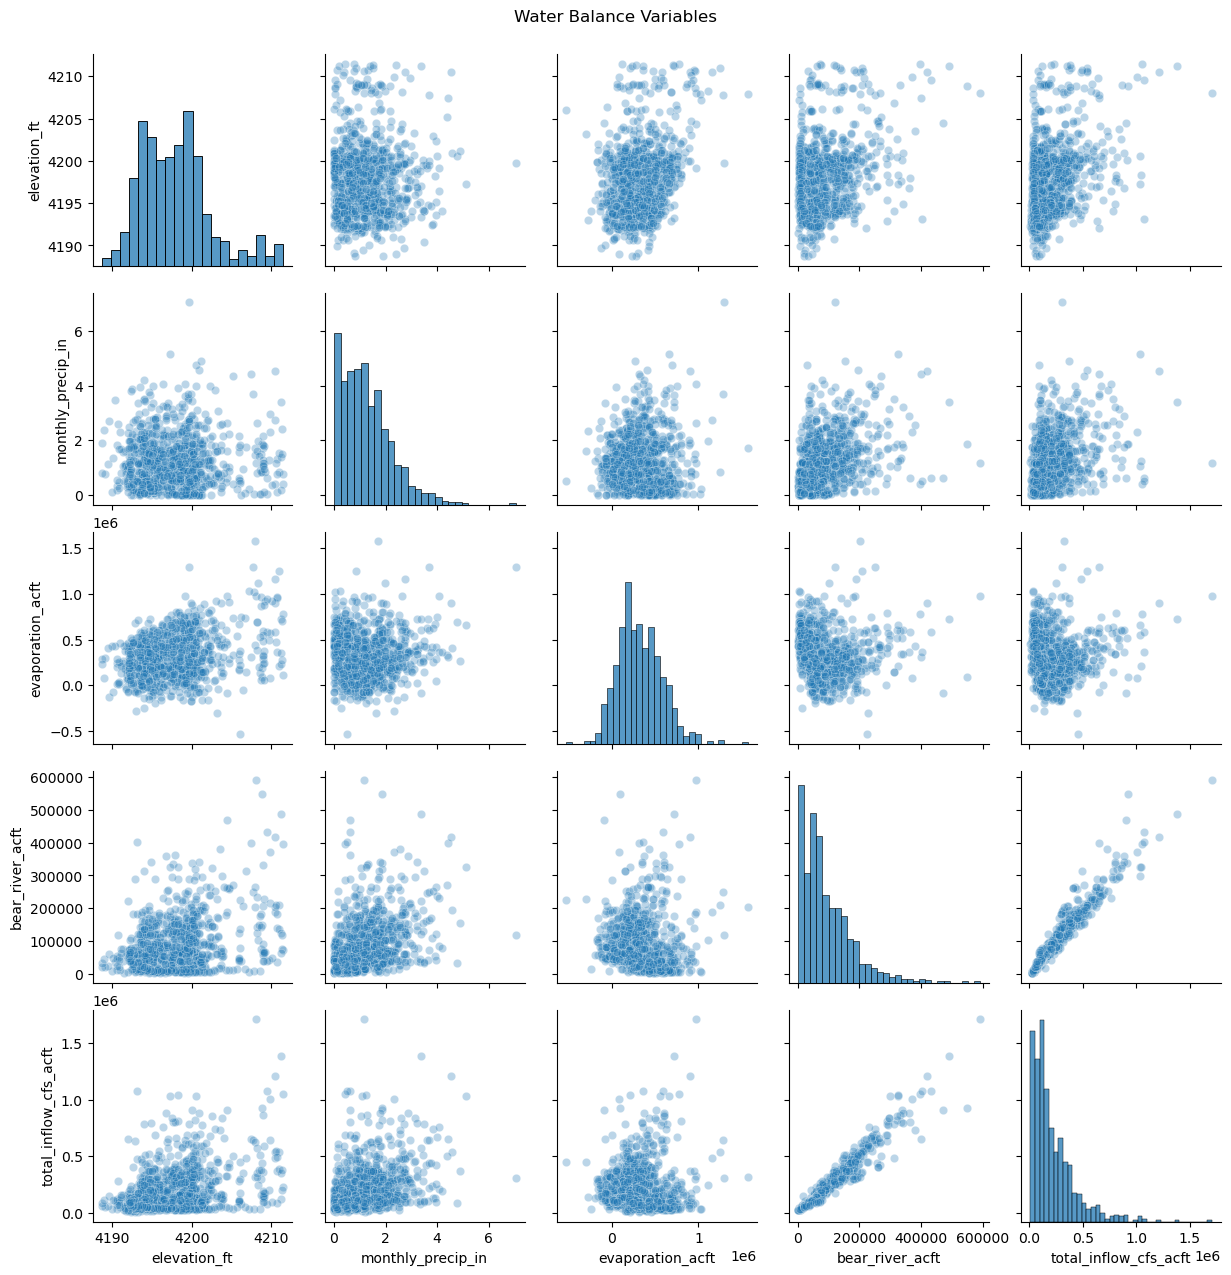

In [197]:
import seaborn as sns
#scatterplot matrix of key variables
#plot 1: main variables
sns.pairplot(gsl_monthly_df[[
    'elevation_ft',
    'monthly_precip_in',
    'evaporation_acft',
    'bear_river_acft',
    'total_inflow_cfs_acft',           
]], plot_kws = {'alpha': 0.3})
plt.suptitle('Water Balance Variables', y = 1.02)
plt.show()


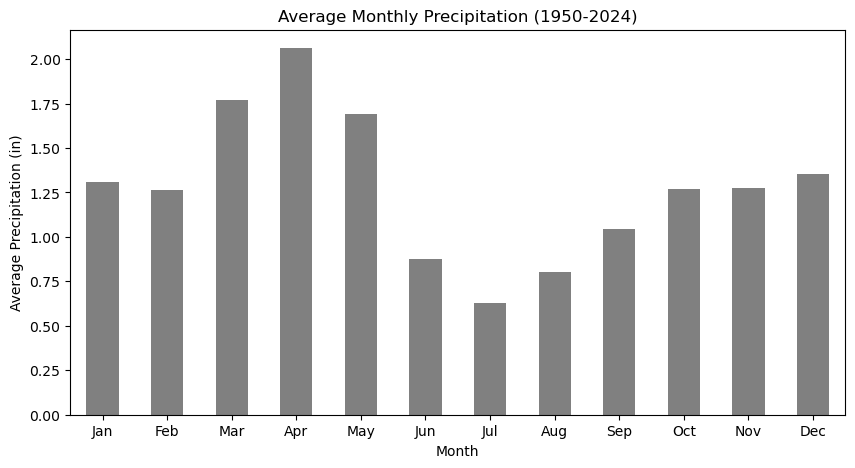

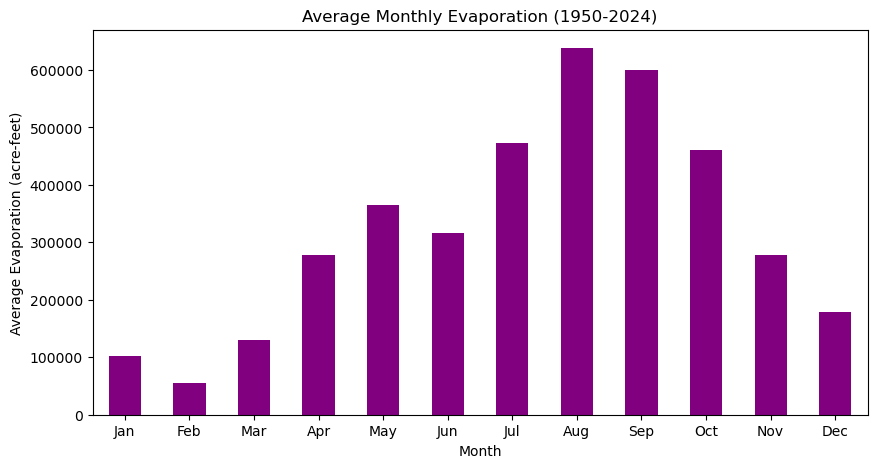

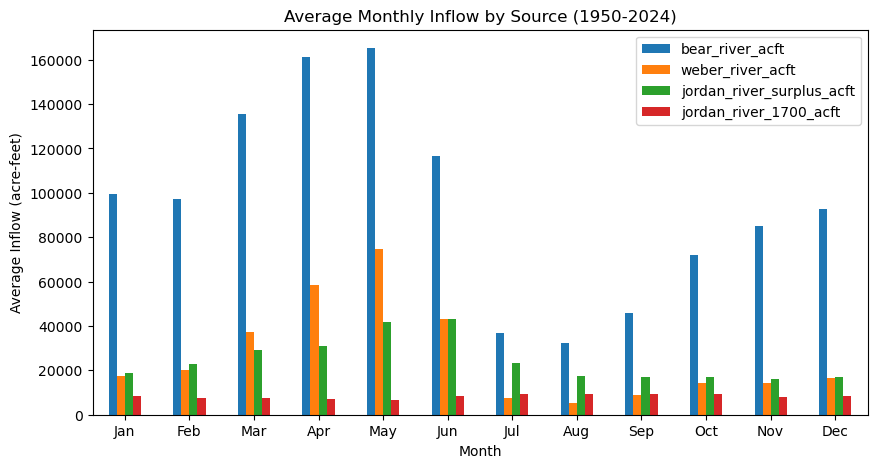

In [203]:
#determine what an average historical precipitation year looks like 
#calculate avg precipitation for each month overtime
monthly_avg_precip = gsl_monthly_df.groupby('month')['monthly_precip_in'].mean()
#plot avg precipitation by month
monthly_avg_precip.plot(kind = 'bar', figsize = (10, 5), title = 'Average Monthly Precipitation (1950-2024)', color = 'gray')
plt.xlabel('Month')
plt.ylabel('Average Precipitation (in)')
plt.xticks(
    ticks = range(12), 
    labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], 
    rotation = 0
)
plt.show()

#calculate avg evaporation for each month overtime
monthly_avg_evap = gsl_monthly_df.groupby('month')['evaporation_acft'].mean()
#plot avg evaporation by month
monthly_avg_evap.plot(kind = 'bar', figsize = (10, 5), title = 'Average Monthly Evaporation (1950-2024)',color = 'purple')
plt.xlabel('Month')
plt.ylabel('Average Evaporation (acre-feet)')
plt.xticks(
    ticks = range(12), 
    labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], 
    rotation = 0
)
plt.show()

#calculate avg inflow for each month overtime
monthly_avg_inflow = gsl_monthly_df.groupby('month')[['bear_river_acft','weber_river_acft','jordan_river_surplus_acft','jordan_river_1700_acft']].mean()

#plot avg inflow by month
monthly_avg_inflow.plot(kind = 'bar', figsize = (10, 5), title = 'Average Monthly Inflow by Source (1950-2024)')
plt.xlabel('Month')
plt.ylabel('Average Inflow (acre-feet)')
plt.xticks(
    ticks = range(12),
    labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'],
    rotation = 0 
)
plt.legend()
plt.show()

Evap skewness: 0.9495114522992564


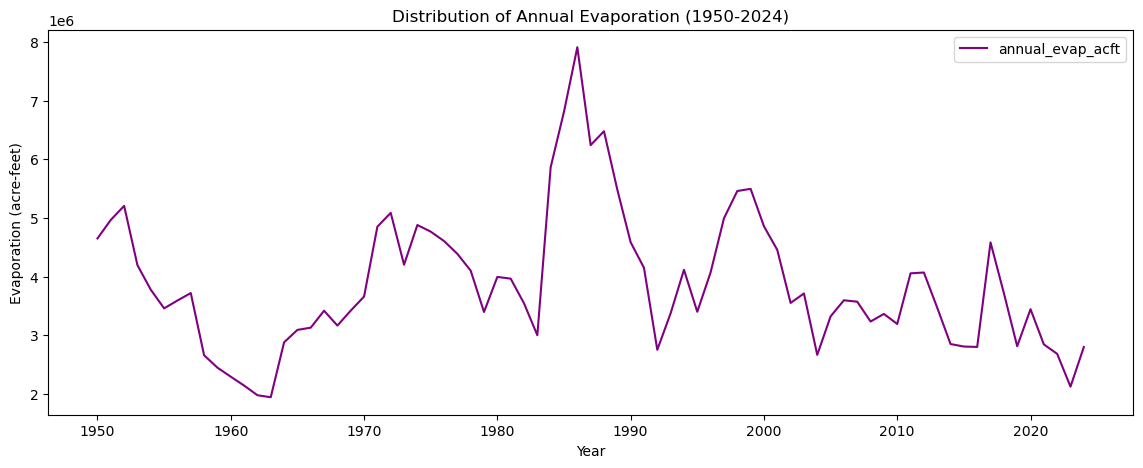

In [205]:
#calculate annual evaporation
annual_evap = gsl_monthly_df.groupby('year')['evaporation_acft'].sum().reset_index()
annual_evap.columns = ['year', 'annual_evap_acft']
#skewness
print('Evap skewness:', annual_evap['annual_evap_acft'].skew())

#plot distribution
annual_evap.plot(
    x = 'year',
    y = 'annual_evap_acft',
    figsize = (14, 5),
    title = 'Annual Evaporation Over Time (1950-2024)',
    color = 'purple'
)
# plot distribution
plt.title('Distribution of Annual Evaporation (1950-2024)')
plt.ylabel('Evaporation (acre-feet)')
plt.xlabel('Year')
plt.show()

### **5. Total Inflow vs Snowpack**

The scatter plot shows that when there is more snow build up in the mountains during winter, more water tends to flow into the lake. This pattern can be seen in the plot where the dots shift higher as you move from left to right. However the pattern is not perfectly linear, meaning that snow is not the only variable that determines how much water reaches the lake.

Note: About 53% of the snowpack data is missing, but still worth looking at since it covers 35 years of data.

475 missing values
424 available values
Start date: 1989-09-01 00:00:00
End date: 2024-12-01 00:00:00


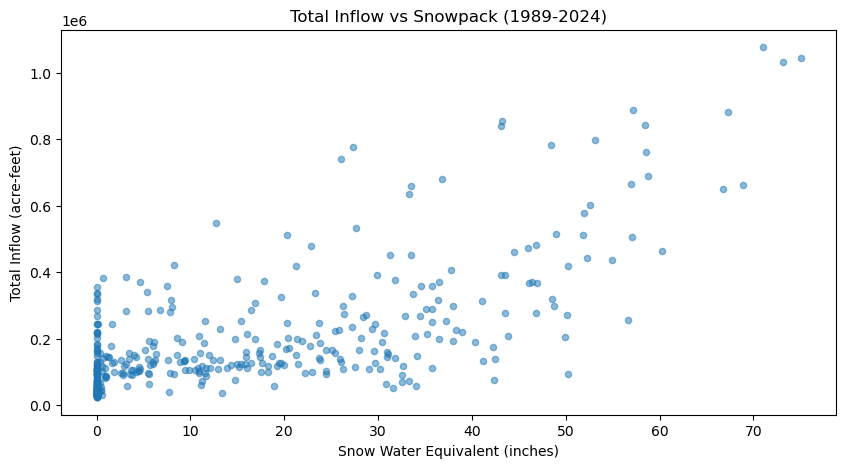

In [214]:
#check how much snowpack data is missing 
print(gsl_monthly_df['snow_water_equiv_in'].isna().sum(), 'missing values')
print(gsl_monthly_df['snow_water_equiv_in'].notna().sum(), 'available values')

#find date range of snowpack data available
snowpack_data = gsl_monthly_df[gsl_monthly_df['snow_water_equiv_in'].notna()]
print('Start date:', snowpack_data['date'].min())
print('End date:', snowpack_data['date'].max())

#filter only rows where snowpack data exists
snow_df = gsl_monthly_df.dropna(subset=['snow_water_equiv_in'])
#scatter plot of snowpack vs total inflow
snow_df.plot.scatter(
    x = 'snow_water_equiv_in',
    y = 'total_inflow_cfs_acft',
    figsize = (10, 5),
    title = 'Total Inflow vs Snowpack (1989-2024)',
    alpha = 0.5
)
plt.xlabel('Snow Water Equivalent (inches)')
plt.ylabel('Total Inflow (acre-feet)')
plt.show()